**1.Clone repo(colab only)**

In [1]:
!git clone https://github.com/MohamedAAbdullah1/NTI-Final-Project.git
%cd NTI-Final-Project

fatal: destination path 'NTI-Final-Project' already exists and is not an empty directory.
/content/NTI-Final-Project


**2.imports**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
%matplotlib inline

**3.Load Data**

In [3]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("data/processed/y_test.csv").values.ravel()
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
X_train.head()


X_train: (13463, 6) | y_train: (13463,)
X_test: (3366, 6) | y_test: (3366,)


,Locality,Latitude,Longitude,Signal Strength (dBm),Latency (ms),Network Type
0,Pataliputra,25.605539,85.285651,-87.611830,164.101054,4G
1,Kidwaipuri,25.491973,85.086669,-90.089704,22.851745,5G
2,Danapur,25.684972,84.989785,-90.175391,139.812003,4G
3,Kankarbagh,25.569868,85.138714,-93.384826,113.904981,4G
4,Phulwari Sharif,25.626811,85.136823,-95.888704,71.291449,4G


**4.Build pipeline(encode categoricals + KNN + Train)**

In [4]:
categorical_cols = ["Locality", "Network Type"]
numeric_cols = ["Latitude", "Longitude", "Signal Strength (dBm)", "Latency (ms)"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid = {
    "model__n_neighbors": range(1, 31),
    "model__weights": ["uniform", "distance"]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_pipeline = grid.best_estimator_

Best params: {'model__n_neighbors': 27, 'model__weights': 'distance'}


**6.Evaluate**

=== KNN Model Performance ===
Mean Absolute Error (MAE) : 6.6088
Mean Squared Error (MSE)  : 180.1659
Root Mean Squared Error (RMSE) : 13.4226
R2 Score                  : 0.7322

Baseline MAE: 19.282386109599546


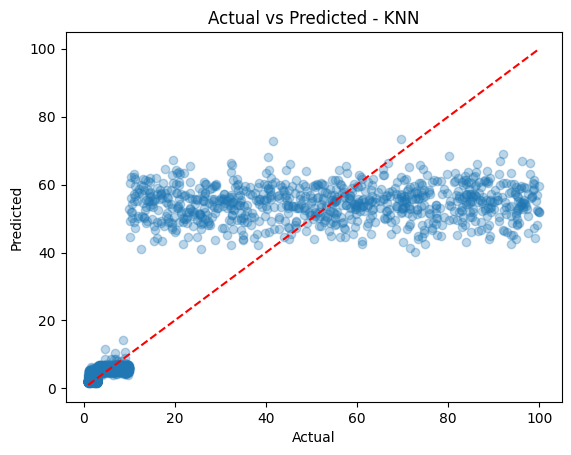

In [5]:
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== KNN Model Performance ===")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R2 Score                  : {r2:.4f}\n")
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print("Baseline MAE:", mean_absolute_error(y_test, y_dummy))

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Actual vs Predicted - KNN")
plt.show()

**7.Save Model**

In [6]:
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'knn_model.pkl')
joblib.dump(best_pipeline, os.path.join(models_dir, 'knn_pipeline.pkl'))

['models/knn_pipeline.pkl']